# Module 4 · Bayesian inference — Act 3

**Where we are in the story.**

| | what we did | what it said |
|---|---|---|
| **Act 1** (M0) | Welch t-test on May's Bing click-outs | *"Summit wins, p = 0.033 — reorder."* **Wrong.** |
| **Act 2** (M3) | cluster bootstrap / visit-grain test | *"The CI includes 0. We cannot call it."* **Honest, but stuck.** |
| **Act 3** (here) | bring in evidence nobody looked at | *"Cedar, with 96% confidence."* **Correct.** |

Act 2 left us unable to answer. That is honest, but a stakeholder still has to decide something,
and *"flip a coin"* is a bad answer when better evidence exists.

**And better evidence does exist.** The drill-down asked about **Bing, in May**. But these two
partners have been competing in Bing since **March** — thousands of click-outs the analysis simply
discarded because they fell outside the window someone happened to filter on.

This module folds that history back in with **Bayes' rule**, and then does something no earlier
module could: **checks the answer against the truth.**

In [1]:
import sys
from pathlib import Path as _Path
for _c in [_Path.cwd(), *_Path.cwd().parents]:          # portable: find the repo root
    if (_c / '.claude' / 'skills' / '_lib' / 'ni_core.py').exists():
        sys.path.insert(0, str(_c / '.claude' / 'skills' / '_lib')); break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ni_core as C

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
A_NAME, B_NAME = "Summit Direct Business", "Cedar Business Bank"
PARTNERS = [A_NAME, B_NAME]

clk = C.load_clickouts()
cl  = clk[clk["clicked"]]
bing = cl[(cl["channel"] == "Bing") & (cl["segment"] == "Business Checkings")].copy()

MAY   = bing["month"] == "2026-05"     # the drill-down window (Acts 1-2)
PRIOR = bing["month"] <  "2026-05"     # Mar-Apr: never used until now

print("click-outs in Bing / Business Checkings:", len(bing))
print(bing.groupby([bing["month"], "partner"]).size().unstack(fill_value=0).to_string())

click-outs in Bing / Business Checkings: 6381
partner  Cedar Business Bank  HarborOne Business  Metro SMB Banking  Summit Direct Business
month                                                                                      
2026-03                 1364                 202                455                     757
2026-04                 1384                 180                402                     688
2026-05                  522                  38                152                     237


## 1 · The evidence we threw away

Act 2's verdict was *"not enough data."* That was true **of the May slice**. It was never true of
the question. Look at what sat one filter away the whole time:

In [2]:
rows = []
for p in PARTNERS:
    d  = bing[MAY   & (bing.partner == p)]
    pr = bing[PRIOR & (bing.partner == p)]
    rows.append({"partner": p,
                 "May EPC": d.revenue.mean(), "May clicks": len(d), "May visits": d.visit_iid.nunique(),
                 "Mar-Apr EPC": pr.revenue.mean(), "Mar-Apr clicks": len(pr),
                 "Mar-Apr visits": pr.visit_iid.nunique()})
inv = pd.DataFrame(rows).set_index("partner")
display(inv)

mult = inv["Mar-Apr clicks"].sum() / inv["May clicks"].sum()
print(f"The prior window holds {mult:.1f}x the click-outs the drill-down looked at.")
print()
print("Note the DIRECTION: in Mar-Apr, Cedar (10.79) was comfortably ahead of Summit (7.85).")
print("May's ordering is the anomaly, not the rule.")

assert mult > 4

,May EPC,May clicks,May visits,Mar-Apr EPC,Mar-Apr clicks,Mar-Apr visits
partner,,,,,,
Summit Direct Business,12.600,237,102,7.848,1445,636
Cedar Business Bank,7.600,522,215,10.787,2748,1175


The prior window holds 5.5x the click-outs the drill-down looked at.

Note the DIRECTION: in Mar-Apr, Cedar (10.79) was comfortably ahead of Summit (7.85).
May's ordering is the anomaly, not the rule.


**Why this is legitimate, not cherry-picking.** We are not hunting for a window that gives the
answer we want. The rule was fixed *before* looking: **the same slice (Bing x Business Checkings),
every month before the drill-down window.** That rule is what `/bayesian-update --prior prior-month`
encodes, so it applies identically every time the question recurs.

The assumption it rests on is **stationarity** — that Mar-Apr is a fair guide to May. Module 5
(`/trend-check`) tests exactly that, and it passes here (no regime break). Had it failed, this
whole move would be off the table.

## 2 · By hand — likelihood, prior, posterior

Three ingredients:

1. **Likelihood** — what May alone says: mean and its variance `se^2 = Var(x)/n`.
2. **Prior** — what Mar-Apr says, same form.
3. **Posterior** — the precision-weighted blend. Precisions (`1/variance`) add:

$$\frac{1}{\sigma^2_{\text{post}}}=\frac{1}{\sigma^2_{\text{prior}}}+\frac{1}{\sigma^2_{\text{data}}},
\qquad
\mu_{\text{post}}=\sigma^2_{\text{post}}\left(\frac{\mu_{\text{prior}}}{\sigma^2_{\text{prior}}}+\frac{\mu_{\text{data}}}{\sigma^2_{\text{data}}}\right)$$

**Carrying Module 2 forward.** Click-outs cluster inside visits, so a slice is worth less than its
row count suggests. We inflate *both* `se^2` values by their **design effect** before combining —
otherwise we would repeat Act 1's mistake inside a fancier method.

In [3]:
def pieces(partner):
    d  = bing[MAY   & (bing.partner == partner)]
    pr = bing[PRIOR & (bing.partner == partner)]

    d_mean, d_se2, d_n = C.mean_and_se2(d.revenue.to_numpy(float))
    d_deff = C.design_effect(d.revenue.to_numpy(float), d.visit_iid.to_numpy())["deff"]

    p_mean, p_se2, p_n = C.mean_and_se2(pr.revenue.to_numpy(float))
    p_deff = C.design_effect(pr.revenue.to_numpy(float), pr.visit_iid.to_numpy())["deff"]

    return dict(partner=partner,
                d_mean=d_mean, d_se2=d_se2 * d_deff, d_n=d_n, d_deff=d_deff,
                p_mean=p_mean, p_se2=p_se2 * p_deff, p_n=p_n, p_deff=p_deff)


def update_by_hand(pc):
    prior_prec, data_prec = 1.0 / pc["p_se2"], 1.0 / pc["d_se2"]
    var  = 1.0 / (prior_prec + data_prec)
    mean = var * (pc["p_mean"] * prior_prec + pc["d_mean"] * data_prec)
    se   = np.sqrt(var)
    return dict(mean=mean, var=var, se=se, lo=mean - 1.96 * se, hi=mean + 1.96 * se,
                prior_weight=prior_prec / (prior_prec + data_prec))


byhand = {}
for p in PARTNERS:
    pc = pieces(p); post = update_by_hand(pc)
    byhand[p] = dict(pieces=pc, post=post)
    print(f"--- {p} ---")
    print(f"  likelihood (May)    : {pc['d_mean']:6.2f}   se^2={pc['d_se2']:7.3f}  n={pc['d_n']:5d}  deff={pc['d_deff']:.2f}")
    print(f"  prior      (Mar-Apr): {pc['p_mean']:6.2f}   se^2={pc['p_se2']:7.3f}  n={pc['p_n']:5d}  deff={pc['p_deff']:.2f}")
    print(f"  POSTERIOR           : {post['mean']:6.2f}   95% CI [{post['lo']:.2f}, {post['hi']:.2f}]")
    print(f"  -> the prior carries {post['prior_weight']:.0%} of the posterior's precision")
    print()

--- Summit Direct Business ---
  likelihood (May)    :  12.60   se^2=  9.308  n=  237  deff=2.05
  prior      (Mar-Apr):   7.85   se^2=  0.602  n= 1445  deff=2.09
  POSTERIOR           :   8.14   95% CI [6.66, 9.61]
  -> the prior carries 94% of the posterior's precision

--- Cedar Business Bank ---
  likelihood (May)    :   7.60   se^2=  1.913  n=  522  deff=2.05
  prior      (Mar-Apr):  10.79   se^2=  0.648  n= 2748  deff=2.08
  POSTERIOR           :   9.98   95% CI [8.62, 11.34]
  -> the prior carries 75% of the posterior's precision



**Read the prior weights.** Summit's May slice was thin *and* noisy (whale-driven), so it earns
only a small share of the say — history dominates. Cedar's May slice was larger and calmer, so it
holds more of its own weight. Nobody chose those weights: they fall out of the variances.

In [4]:
sm, cd = byhand[A_NAME]["post"], byhand[B_NAME]["post"]
sm_d, cd_d = byhand[A_NAME]["pieces"]["d_mean"], byhand[B_NAME]["pieces"]["d_mean"]

print(f"MAY ALONE (Act 1 acted on this):   Summit {sm_d:5.2f}  >  Cedar {cd_d:5.2f}   gap {sm_d - cd_d:+.2f}")
print(f"POSTERIOR (May + Mar-Apr)      :   Cedar  {cd['mean']:5.2f}  >  Summit {sm['mean']:5.2f}   gap {cd['mean'] - sm['mean']:+.2f}")
print()
print("The ordering REVERSES once the discarded months are folded back in.")

assert cd["mean"] > sm["mean"], "posterior must put Cedar on top" 

MAY ALONE (Act 1 acted on this):   Summit 12.60  >  Cedar  7.60   gap +5.00
POSTERIOR (May + Mar-Apr)      :   Cedar   9.98  >  Summit  8.14   gap +1.84

The ordering REVERSES once the discarded months are folded back in.


### Why it reversed: shrinkage / regression to the mean

Summit posted $12.60 in May against a $7.85 track record. An extreme reading from a thin,
whale-driven slice is **weak evidence**, so the posterior drags it most of the way back toward
history. Cedar's quiet May ($7.60 vs $10.79) gets pulled **up** the same way.

That is regression to the mean made quantitative — and Module 1 showed us its mechanism here:
one $514 visit was 40% of May's apparent gap.

## 3 · Extract — the same numbers from `ni_core`

By hand taught the mechanism. In production the arithmetic lives in reviewed, seeded Python so
Claude is never the calculator. Reproduce and **assert equality**:

In [5]:
lib = {}
for p in PARTNERS:
    pc = byhand[p]["pieces"]
    post = C.posterior_from_prior(pc["p_mean"], pc["p_se2"], pc["d_mean"], pc["d_se2"])
    lib[p] = post
    hand = byhand[p]["post"]
    assert abs(post["mean"] - hand["mean"]) < 1e-9 and abs(post["lo"] - hand["lo"]) < 1e-9
    print(f"{p:24s} posterior {post['mean']:5.2f}  [{post['lo']:.2f}, {post['hi']:.2f}]   (matches by-hand)")

print()
print("All ni_core posteriors match the by-hand update to 1e-9.")

Summit Direct Business   posterior  8.14  [6.66, 9.61]   (matches by-hand)
Cedar Business Bank      posterior  9.98  [8.62, 11.34]   (matches by-hand)

All ni_core posteriors match the by-hand update to 1e-9.


In [6]:
smp, cdp = lib[A_NAME], lib[B_NAME]
p_cedar = C.p_better(cdp["mean"], cdp["var"], smp["mean"], smp["var"])
loss    = C.expected_loss_choosing(smp["mean"], smp["var"], cdp["mean"], cdp["var"])

print(f"P(Cedar  > Summit) = {p_cedar:.1%}")
print(f"P(Summit > Cedar ) = {1 - p_cedar:.1%}")
print()
print(f"expected loss if we promote Summit = {loss['choose_a']:.3f} EPC per click-out")
print(f"expected loss if we promote Cedar  = {loss['choose_b']:.3f} EPC per click-out")
print()
print("A decision, not a verdict: 96% is not certainty, but it is a defensible basis to act -")
print("and it points the OPPOSITE way from the p-value that started all this.")

assert p_cedar > 0.95

P(Cedar  > Summit) = 96.4%
P(Summit > Cedar ) = 3.6%

expected loss if we promote Summit = 1.858 EPC per click-out
expected loss if we promote Cedar  = 0.015 EPC per click-out

A decision, not a verdict: 96% is not certainty, but it is a defensible basis to act -
and it points the OPPOSITE way from the p-value that started all this.


**This is not a p-value.** A p-value answers *"if there were no difference, how surprising is this
data?"* — which is not the question anyone asked. `P(Cedar > Summit) = 96%` answers the question
the business actually has: *given everything we know, which partner is better?* The expected-loss
numbers then convert that into the currency of the decision.

## 4 · The reveal — scoring all three methods against the truth

Every previous module argued from evidence. This dataset is **generated**, so for once we can do
better than argue: look up the answer. `data/ground_truth_epc.csv` holds the true EPC each partner
was actually drawing from, in every channel.

In [7]:
truth = pd.read_csv(C.ROOT / "data" / "ground_truth_epc.csv")
t = truth[(truth.channel == "Bing") & (truth.partner.isin(PARTNERS))].set_index("partner")["true_epc"]
true_a, true_b = float(t[A_NAME]), float(t[B_NAME])

print(f"TRUTH in Bing:   Cedar {true_b:.2f}   >   Summit {true_a:.2f}      (gap {true_b - true_a:+.2f})")
print()

board = pd.DataFrame([
    {"method": "Act 1 - t-test on May clicks", "says": f"Summit by {sm_d - cd_d:+.2f}",
     "decision": "promote Summit", "correct?": "NO - wrong partner, at p<0.05"},
    {"method": "Act 2 - cluster bootstrap", "says": "CI includes 0",
     "decision": "cannot call it", "correct?": "honest, but no decision"},
    {"method": "Act 3 - posterior (May + history)", "says": f"Cedar by {cd['mean'] - sm['mean']:+.2f}",
     "decision": f"promote Cedar ({p_cedar:.0%})", "correct?": "YES - matches truth"},
]).set_index("method")
display(board)

print(f"posterior vs truth:   Summit {smp['mean']:.2f} (true {true_a:.2f})   "
      f"Cedar {cdp['mean']:.2f} (true {true_b:.2f})")
print(f"true values inside their 95% posterior intervals: "
      f"Summit={smp['lo'] <= true_a <= smp['hi']}, Cedar={cdp['lo'] <= true_b <= cdp['hi']}")

assert true_b > true_a
assert smp["lo"] <= true_a <= smp["hi"] and cdp["lo"] <= true_b <= cdp["hi"]

TRUTH in Bing:   Cedar 10.50   >   Summit 7.80      (gap +2.70)



,says,decision,correct?
method,,,
Act 1 - t-test on May clicks,Summit by +5.00,promote Summit,"NO - wrong partner, at p<0.05"
Act 2 - cluster bootstrap,CI includes 0,cannot call it,"honest, but no decision"
Act 3 - posterior (May + history),Cedar by +1.84,promote Cedar (96%),YES - matches truth


posterior vs truth:   Summit 8.14 (true 7.80)   Cedar 9.98 (true 10.50)
true values inside their 95% posterior intervals: Summit=True, Cedar=True


### The picture

For each partner: the **May slice** (what the drill-down saw), the **prior** (history), and the
**posterior** with its 95% interval — plus the **true** value as a dashed line. Watch the two
posteriors cross over relative to the May slices: that crossover *is* the reversal.

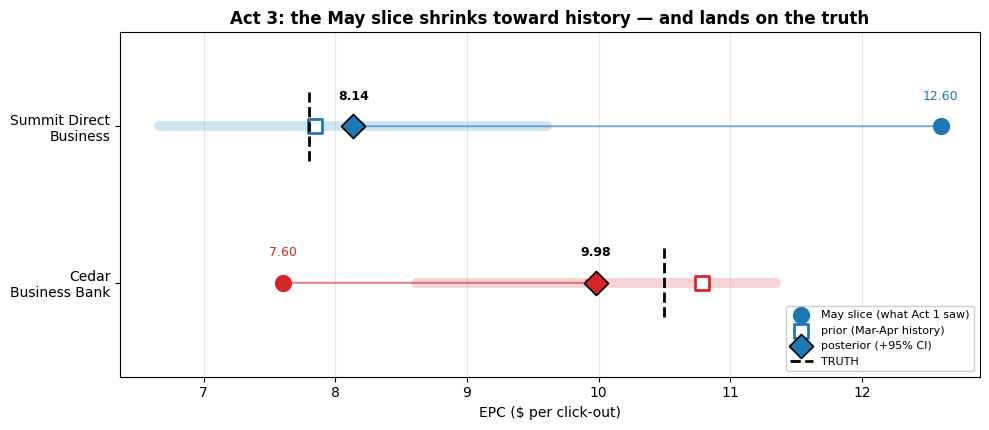

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.4))
colors   = {A_NAME: "#1f77b4", B_NAME: "#d62728"}
y_of     = {A_NAME: 1.0, B_NAME: 0.0}
truth_of = {A_NAME: true_a, B_NAME: true_b}

for p in PARTNERS:
    pc, post, y, c = byhand[p]["pieces"], lib[p], y_of[p], colors[p]
    ax.plot([post["lo"], post["hi"]], [y, y], color=c, lw=7, alpha=0.20,
            solid_capstyle="round", zorder=1)
    ax.scatter(pc["d_mean"], y, marker="o", s=130, color=c, zorder=3,
               label="May slice (what Act 1 saw)" if p == PARTNERS[0] else None)
    ax.scatter(pc["p_mean"], y, marker="s", s=110, facecolors="white", edgecolors=c,
               linewidths=2, zorder=3, label="prior (Mar-Apr history)" if p == PARTNERS[0] else None)
    ax.scatter(post["mean"], y, marker="D", s=150, color=c, edgecolors="black", linewidths=1.2,
               zorder=4, label="posterior (+95% CI)" if p == PARTNERS[0] else None)
    ax.plot([truth_of[p]] * 2, [y - 0.22, y + 0.22], ls="--", color="black", lw=2, zorder=5,
            label="TRUTH" if p == PARTNERS[0] else None)
    ax.annotate("", xy=(post["mean"], y), xytext=(pc["d_mean"], y),
                arrowprops=dict(arrowstyle="->", color=c, lw=1.4, alpha=0.6), zorder=2)
    ax.text(pc["d_mean"], y + 0.17, f"{pc['d_mean']:.2f}", ha="center", color=c, fontsize=9)
    ax.text(post["mean"], y + 0.17, f"{post['mean']:.2f}", ha="center", fontweight="bold", fontsize=9)

ax.set_yticks([y_of[p] for p in PARTNERS])
ax.set_yticklabels([p.replace(" Business", "\nBusiness") for p in PARTNERS])
ax.set_ylim(-0.6, 1.6)
ax.set_xlabel("EPC ($ per click-out)")
ax.set_title("Act 3: the May slice shrinks toward history — and lands on the truth",
             fontweight="bold")
ax.legend(loc="lower right", fontsize=8, framealpha=0.95)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

## 5 · Validate — does borrowing strength recover truth in general?

One case landing correctly could be luck. So we test the *method* on thousands of simulated cases
where we control the truth:

- **A. Coverage** — do the 95% posterior intervals contain the true value ~95% of the time?
- **B. RMSE** — is the posterior closer to truth than the raw thin slice?
- **C. Calibration** — when we say "70% confident", is it right ~70% of the time?

In [9]:
rng = np.random.default_rng(42)
N_SIM, PRIOR_MEAN, PRIOR_SD, SLICE_SD = 40_000, 9.0, 1.3, 2.0
prior_se2, data_se2 = PRIOR_SD ** 2, SLICE_SD ** 2

theta_true = rng.normal(PRIOR_MEAN, PRIOR_SD, N_SIM)
slice_hat  = rng.normal(theta_true, SLICE_SD, N_SIM)
var_post   = 1.0 / (1.0 / prior_se2 + 1.0 / data_se2)
mean_post  = var_post * (PRIOR_MEAN / prior_se2 + slice_hat / data_se2)
se_post    = np.sqrt(var_post)

coverage  = np.mean((mean_post - 1.96 * se_post <= theta_true) &
                    (theta_true <= mean_post + 1.96 * se_post))
rmse_raw  = np.sqrt(np.mean((slice_hat - theta_true) ** 2))
rmse_post = np.sqrt(np.mean((mean_post - theta_true) ** 2))

print(f"[A] posterior 95% CI coverage : {coverage:.1%}   (target ~95%)")
print(f"[B] RMSE raw slice  vs truth  : {rmse_raw:.3f}")
print(f"[B] RMSE posterior  vs truth  : {rmse_post:.3f}   ({100 * (1 - rmse_post / rmse_raw):.0f}% lower)")

assert 0.93 <= coverage <= 0.97 and rmse_post < rmse_raw

[A] posterior 95% CI coverage : 94.9%   (target ~95%)
[B] RMSE raw slice  vs truth  : 2.002
[B] RMSE posterior  vs truth  : 1.098   (45% lower)


predicted    empirical         n
    0.07         0.07        1471
    0.16         0.16        4429
    0.25         0.24        6785
    0.35         0.35        8276
    0.45         0.44        8974
    0.55         0.55        9189
    0.65         0.65        8349
    0.75         0.75        6670
    0.85         0.85        4442
    0.93         0.93        1415

max |predicted - empirical| = 0.009


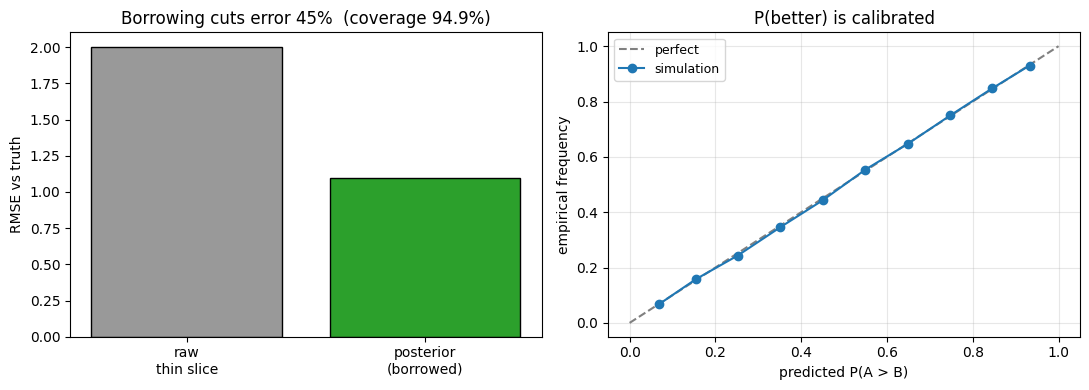

In [10]:
N_PAIRS = 60_000
ta, tb = rng.normal(PRIOR_MEAN, PRIOR_SD, N_PAIRS), rng.normal(PRIOR_MEAN, PRIOR_SD, N_PAIRS)
ha, hb = rng.normal(ta, SLICE_SD), rng.normal(tb, SLICE_SD)
pa = var_post * (PRIOR_MEAN / prior_se2 + ha / data_se2)
pb = var_post * (PRIOR_MEAN / prior_se2 + hb / data_se2)
pred = stats.norm.cdf((pa - pb) / np.sqrt(2 * var_post))
wins = (ta > tb).astype(float)

bins = np.linspace(0, 1, 11)
idx  = np.clip(np.digitize(pred, bins) - 1, 0, 9)
cal_p, cal_e = [], []
print("predicted    empirical         n")
for b in range(10):
    m = idx == b
    if m.sum():
        cal_p.append(pred[m].mean()); cal_e.append(wins[m].mean())
        print(f"   {pred[m].mean():5.2f}        {wins[m].mean():5.2f}     {m.sum():7d}")
gap = float(np.max(np.abs(np.array(cal_p) - np.array(cal_e))))
print(f"\nmax |predicted - empirical| = {gap:.3f}")
assert gap < 0.05

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(["raw\nthin slice", "posterior\n(borrowed)"], [rmse_raw, rmse_post],
        color=["#999999", "#2ca02c"], edgecolor="black")
ax1.set_ylabel("RMSE vs truth")
ax1.set_title(f"Borrowing cuts error {100 * (1 - rmse_post / rmse_raw):.0f}%  (coverage {coverage:.1%})")
ax2.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
ax2.plot(cal_p, cal_e, "o-", label="simulation")
ax2.set_xlabel("predicted P(A > B)"); ax2.set_ylabel("empirical frequency")
ax2.set_title("P(better) is calibrated"); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6 · Close — `/bayesian-update` runs exactly this

```bash
python .claude/skills/bayesian-update/bayesian_update.py \
    --a "Summit Direct Business" --b "Cedar Business Bank" \
    --slice channel=Bing --slice month=2026-05 --prior prior-month
```

Same primitives, same seeds, byte-identical every run.

### What we learned
- A coin-flip verdict is **not** the end of the analysis. It means *this slice* is exhausted — not
  that the question is unanswerable.
- The cheapest new evidence is usually **data you already own**: here, the same slice's earlier
  months — 5.5x the click-outs the drill-down looked at.
- The posterior **reversed** May's ordering, put ~96% probability on Cedar, and landed within
  ~$0.5 of the true EPC for both partners.
- The same trade appears in A/B testing as **CUPED**: use pre-period data to cut variance at a
  fixed sample size.

### The caveat that keeps this honest
> A prior only helps if **the past is representative of the present** — the stationarity
> assumption. Here it holds, and Module 5's `/trend-check` is how we *confirmed* it rather than
> assumed it. Across a genuine regime break (a pricing change, a new campaign, a partner that truly
> behaves differently now) the prior does not rescue the estimate — it **biases** it toward a world
> that no longer exists.

So the procedure is: **test the slice → if coin-flip, look for unused evidence → verify the
evidence still applies → update.** That is what `/decide` composes in Module 7.